In [28]:
# =============================================================================
# USER CONFIGURATION
# =============================================================================
# This section defines all user-editable parameters and derived paths.
# Adjust these values as needed for each new calibration run.
# =============================================================================

from pathlib import Path
import os
import re
import json
import time
import shutil
import subprocess
import numpy as np
import pandas as pd
import os
from pathlib import Path
import os
import re
import json
import time
import shutil
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import re

import sklearn.metrics as skm
import math # Import math library

# --- Base project directory ---
base_dir = Path("/Users/jakobwerkgarner/code/Master_Delta")


# --- Calibration log file ---
#   This file defines the parameter set and split configuration.
#   Only the filename should be changed between calibration runs.
calibration_log_filename = (
    "2025_07_1016_calib_log_dsnow_calib_Win21forced_high_rho0_drpped_stations.txt"
)



calib_language = "R"


# stations = [
#     "Adelboden",
#     "Gadmen",
#     "Grindelwald_Bort",
#     "Gsteig",
#     "Gantrisch",
#     "Leysin",
#     "Saanenmoeser",
#     "Wengen",
#     "Srenberg",
#     "Stoos",
#     "Braunwald",
#     "Malbun",
#     "Binn",
#     "Bourg_St_Pierre",
#     "Fionnay",
#     "Grimentz",
#     "Lauchernalp",
#     "Montana",
#     "Muenster",
#     "Saas_Fee",
#     "Simplon_Dorf",
#     "Wiler",
#     "Bivio",
#     "Obersaxen",
#     "Pusserein",
#     "Sedrun",
#     "Spluegen",
#     "Vals",
#     "Weisfluh_Joch",
#     "Bosco_Gurin",
#     "Maloja",
#     "Sankt_Moritz",
#     "Samnaun"
# ] # high_rho0_drpped_stations

#--- Stations to include in the validation ---
stations = [
    "Adelboden",
    "Gadmen",
    "Grindelwald_Bort",
    "Gsteig",
    "Gantrisch",
    "Leysin",
    "Muerren",
    "Saanenmoeser",
    "Wengen",
    "Srenberg",
    "Stoos",
    "Braunwald",
    "Malbun",
    "St_Margrethenberg",
    "Binn",
    "Bourg_St_Pierre",
    "Fionnay",
    "Grimentz",
    "Lauchernalp",
    "Montana",
    "Muenster",
    "Saas_Fee",
    "Simplon_Dorf",
    "Ulrichen",
    "Wiler",
    "Bivio",
    "Davos_Flueelastr",
    "Juf",
    "Obersaxen",
    "Pusserein",
    "St_Antoenien",
    "Sedrun",
    "Spluegen",
    "Vals",
    "Weisfluh_Joch",
    "Bosco_Gurin",
    "San_Bernadino",
    "Maloja",
    "Sankt_Moritz",
    "Samnaun",
    "Zuoz"
]


stations = [
    "Gadmen",
    "Grindelwald_Bort",
    "Gantrisch",
    "Wengen",
    "Stoos",
    "Braunwald",
    "Fionnay",
    "Grimentz",
    "Lauchernalp",
    "Montana",
    "Muenster",
    "Saas_Fee",
    "Obersaxen",
    "Pusserein",
    "Sedrun",
    "Spluegen",
    "Bosco_Gurin",
    "Samnaun",
    "Zuoz"
]  # random_stations_50p

# --- Years to process ---
years = [1617, 1718, 1819, 1920, 2021, 2122]





# --- Path to R bulk-SWE driver script ---
r_script_path_dsnow_bulk = (
    base_dir
    / "calibration"
    / "new_snow_rho_HNW"
    / "model_run_for_bulk_swe.R"
)

In [29]:


# Root for this calibration workflow
CALIB_ROOT = base_dir / "calibration" / "new_snow_rho_HNW"

# Inputs
DIR_INPUTS = CALIB_ROOT / "inputs" / "seasonal_data"  # contains per-year model_input CSVs

# Temporary + intermediate outputs (bulk run)
DIR_TEMP_BULK = CALIB_ROOT / "tmp" / "bulk"

# Structured intermediate outputs for validation
DIR_PER_SEASON  = CALIB_ROOT / "tmp" / "bulk" / "per_season"                 # per-year per-station CSVs
DIR_ALL_SEAS  = CALIB_ROOT / "tmp" / "bulk" / "per_station_all_seasons"  # merged all-seasons per station

if calib_language == "R":

    # Final validated outputs (all stations merged)
    DIR_VALIDATED = CALIB_ROOT / "outputs"  / "bulk" / "validated_all_stations"

    calibration_log_path = (
    base_dir
    / "calibration"
    / "calibration_logsx"
    / "A_log_files"
    / calibration_log_filename
)

    

if calib_language == "python":

    # Final validated outputs (all stations merged)
    DIR_VALIDATED = CALIB_ROOT / "outputs"  /"python_calib" / "bulk" / "validated_all_stations"

        # --- Derived full path to calibration log ---
    calibration_log_path = (
        base_dir
        / "calibration"
        / "calibration_logsx"
        / "python_logs"
        / calibration_log_filename
    )


# Make sure these exist early
for d in (DIR_INPUTS, DIR_TEMP_BULK, DIR_PER_SEASON, DIR_ALL_SEAS, DIR_VALIDATED):
    d.mkdir(parents=True, exist_ok=True)

# Input model_input.csv locations
def make_model_input_path(year: int, station: str) -> str:
    """
    Build path to the per-station, per-year model_input file:
        <CALIB_ROOT>/inputs/model_input_hnw_validation/<year>/<station>_HS_HNW.csv
    """
    filename = f"{station}_HS_HNW.csv"
    return str(DIR_INPUTS / str(int(year)) / filename)


RSCRIPT_BIN = "/usr/local/bin/Rscript"


WORKDIR = base_dir


In [30]:
# -----------------------------------------------------------------------------
# R RUNNER
# -----------------------------------------------------------------------------
def run_bulk_swe(model_input_csv: str, log_path: str, r_script_path: str) -> str:
    """
    Run the bulk-SWE R driver with:
        Rscript model_run_for_bulk_swe.R <model_input.csv> <calibration_log.txt>
    and return the output CSV path printed by the script (absolute path).
    """
    print(f"[RUN] Using calibration log: {calibration_log_path}")
    print(f"[RUN] Parsed rho_0 = {extract_rho_0_from_log(calibration_log_path)}")
    model_input_csv = os.path.abspath(model_input_csv)
    log_path = os.path.abspath(log_path)
    r_script_path = os.path.abspath(r_script_path)

    if not os.path.exists(model_input_csv):
        raise FileNotFoundError(f"model_input not found: {model_input_csv}")

    # Ensure the log file exists (and its directory)
    os.makedirs(os.path.dirname(log_path) or ".", exist_ok=True)
    if not os.path.exists(log_path):
        open(log_path, "a").close()

    proc = subprocess.run(
        [RSCRIPT_BIN, r_script_path, model_input_csv, log_path],
        cwd=WORKDIR or (os.path.dirname(r_script_path) or None),
        capture_output=True,
        text=True,
        check=False,
    )
    stdout = (proc.stdout or "").strip()
    stderr = (proc.stderr or "").strip()

    if proc.returncode != 0:
        raise RuntimeError(
            f"R script failed (exit {proc.returncode}).\n--- STDOUT ---\n{stdout}\n--- STDERR ---\n{stderr}"
        )
    if not stdout:
        raise RuntimeError("R script produced empty stdout; expected a CSV path.")

    # Last non-empty line is the path; normalize to absolute
    out_path = [ln.strip() for ln in stdout.splitlines() if ln.strip()][-1]
    if not os.path.isabs(out_path):
        out_path = os.path.abspath(os.path.join(WORKDIR or os.getcwd(), out_path))
    return out_path

# -----------------------------------------------------------------------------
# I/O HELPERS
# -----------------------------------------------------------------------------


def extract_rho_0_from_log(log_path: str) -> float:
    """
    Extract rho_0 (rho.null or rho_null) from the calibration log file.
    Supports decimals and scientific notation.
    Matches both dot and underscore naming conventions.
    """
    # Match either "rho.null" or "rho_null", with optional spaces and = sign
    pat = re.compile(r"rho[._]null\s*=\s*([0-9.eE+\-]+)")

    with open(log_path, "r") as f:
        for line in f:
            m = pat.search(line)
            if m:
                try:
                    return float(m.group(1))
                except ValueError:
                    continue  # skip malformed numeric entries if any

    raise ValueError("rho.null or rho_null not found in calibration log.")

def ensure_dirs():
    for d in (DIR_TEMP_BULK, DIR_PER_SEASON, DIR_ALL_SEAS, DIR_VALIDATED):
        os.makedirs(d, exist_ok=True)

def read_r_output_with_header(path_csv: str) -> pd.DataFrame:
    """
    Read R output with 3 header lines (# model_input, # log_path, # created_utc) + body:
      date (YYYY-MM-DD), hs (m), SWE (mm).
    """
    with open(path_csv, "r") as f:
        # Optional: consume header lines
        _h1 = f.readline().strip()
        _h2 = f.readline().strip()
        _h3 = f.readline().strip()
        df = pd.read_csv(f)
    required = {"date", "hs", "SWE"}
    if not required.issubset(df.columns):
        raise ValueError(f"Expected columns {required} in {path_csv}")
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    return df

def load_model_input(path_csv: str) -> pd.DataFrame:
    """
    Load model_input CSV (Time, HS[, HNW]). Normalize date to 'YYYY-MM-DD'.
    """
    mi = pd.read_csv(path_csv)
    if "Time" not in mi.columns or "HS" not in mi.columns:
        raise ValueError(f"Expected 'Time' and 'HS' in {path_csv}")
    mi["Time"] = pd.to_datetime(mi["Time"], errors="coerce")
    mi["date"] = mi["Time"].dt.normalize().dt.strftime("%Y-%m-%d")
    mi = mi.drop(columns=["Time"])
    return mi

def write_csv_with_header(df: pd.DataFrame, out_path: str, header_lines: list[str]):
    """
    Write comment header lines then CSV body.
    """
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with open(out_path, "w") as f:
        for line in header_lines:
            f.write(f"# {line}\n")
        df.to_csv(f, index=False)

def clear_temp_bulk_if_new_validated():
    """
    Clears the DIR_TEMP_BULK directory only if DIR_VALIDATED contains
    a file created less than a minute ago.
    """
    validated_files = [
        os.path.join(DIR_VALIDATED, f)
        for f in os.listdir(DIR_VALIDATED)
        if os.path.isfile(os.path.join(DIR_VALIDATED, f))
    ]
    now = time.time()
    recent_file = any(now - os.path.getctime(f) < 60 for f in validated_files)
    if recent_file:
        for root, dirs, files in os.walk(DIR_TEMP_BULK, topdown=False):
            for name in files:
                os.remove(os.path.join(root, name))
            for name in dirs:
                shutil.rmtree(os.path.join(root, name))
        print(f"[INFO] Cleared temporary directory: {DIR_TEMP_BULK}")
    else:
        print("[INFO] No new validated file found; temporary directory not cleared.")

# -----------------------------------------------------------------------------
# HEADER PARSING FROM CALIBRATION LOG (BEST-EFFORT)
# -----------------------------------------------------------------------------
def parse_header_from_log(log_path: str) -> list[str]:
    """
    Try to extract:
      - calibration_log_file
      - split.type, split.seed, ratio.fit
      - 'Optimal parameters' block (if present)
    """
    header = [f"calibration_log_file: {log_path}"]
    try:
        with open(log_path, "r") as f:
            lines = f.readlines()
    except Exception:
        return header

    # Simple key=value lines
    for key in ("split.type", "split.seed", "ratio.fit"):
        m = next((ln for ln in lines if re.search(rf"^\s*{re.escape(key)}\s*=", ln)), None)
        if m:
            header.append(m.strip().lstrip("#").strip())

    # Optimal parameters section (if any)
    opt_idx = next((i for i, ln in enumerate(lines) if re.search(r"Optimal parameters", ln, re.I)), None)
    if opt_idx is not None:
        header.append("Optimal parameters:")
        for j in range(opt_idx + 1, min(opt_idx + 30, len(lines))):
            ln = lines[j].rstrip("\n")
            if not ln.strip():
                break
            if re.match(r"^\s*[-=]{3,}\s*$", ln):
                break
            header.append(ln.strip().lstrip("#").strip())
    return header

# -----------------------------------------------------------------------------
# FEATURE ENGINEERING FOR VALIDATION TABLES
# -----------------------------------------------------------------------------
def add_calendar_and_errors(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds month, month_name, doy, season and error metrics:
    err = HNW_mod - HNW_obs; abs_err; sq_err; ape (%).
    """
    out = df.copy()
    dt = pd.to_datetime(out["date"], errors="coerce")
    out["year"] = dt.dt.year
    out["month"] = dt.dt.month
    out["doy"] = dt.dt.dayofyear

    # Meteorological season
    def season_of(m):
        if m in (12, 1, 2): return "DJF"
        if m in (3, 4, 5):  return "MAM"
        if m in (6, 7, 8):  return "JJA"
        return "SON"
    out["season"] = out["month"].apply(season_of)

    # Errors (only where both modeled and observed HNW exist)
    out["err"] = out["HNW_mod"] - out["HNW_obs"]
    out["abs_err"] = out["err"].abs()
    out["sq_err"] = out["err"] ** 2


    return out

# -----------------------------------------------------------------------------
# MAIN
# -----------------------------------------------------------------------------
def main():
    ensure_dirs()
    header_common = parse_header_from_log(calibration_log_path)

    all_station_rows = []  # collected for final merge

    for station in stations:
        per_year_paths = []

        for year in years:
            model_input_path = make_model_input_path(year, station)

            # 1) Run R and get output CSV path
            out_csv_path = run_bulk_swe(
                model_input_csv=model_input_path,
                log_path=calibration_log_path,
                r_script_path=r_script_path_dsnow_bulk
            )
            print(f"[R] Created: {out_csv_path}")

            # 2) Read outputs + inputs
            model_output = read_r_output_with_header(out_csv_path)     # date, hs (m), SWE (mm)
            model_input  = load_model_input(model_input_path)          # date, HS [cm], (optional) HNW [mm]

            # 3) Build validation df focused on SWE/HNW
            swe_tbl = model_output[["date", "SWE"]].rename(columns={"SWE": "SWE_mod"})
            val = model_input.merge(swe_tbl, on="date", how="left")

            # HNW_obs if present, else NaN
            if "HNW" in model_input.columns:
                val.rename(columns={"HNW": "HNW_obs", "HS": "HS_obs"}, inplace=True)
            else:
                val.rename(columns={"HS": "HS_obs"}, inplace=True)
                val["HNW_obs"] = np.nan


            # Modeled increment (diff of SWE_mod)
            val = val.sort_values("date").reset_index(drop=True)
            val["HNW_mod"] = val["SWE_mod"].diff()
            if not val.empty:

                val.loc[0, "HNW_mod"] = 0.0

            # HS_diff to identify module usage
            val["hs_diff"] = val["HS_obs"].diff()

            # Station tags
            val["station"] = station
            val["year"] = year

            # Calendar + error columns
            val = add_calendar_and_errors(val)

            # 4) Save per-year result
            per_year_name = f"{year}_{station}_bulk_validation.csv"
            per_year_path = str(DIR_PER_SEASON / per_year_name)
            write_csv_with_header(val, per_year_path, header_common)
            print(f"[WRITE] Per-season validation -> {per_year_path}")
            per_year_paths.append(per_year_path)

            # Accumulate for final merge
            all_station_rows.append(val)

        # 5) After all years for this station: merge to an all-seasons per-station file
        if per_year_paths:
            dfs = [pd.read_csv(p, comment="#") for p in per_year_paths]
            st_all = pd.concat(dfs, ignore_index=True)
            st_all = st_all.sort_values(["date"]).drop_duplicates(subset=["station", "date"], keep="last")

            all_season_path = str(DIR_ALL_SEAS / f"{station}_bulk_validation_all_seasons.csv")
            write_csv_with_header(st_all, all_season_path, header_common)
            print(f"[WRITE] All-seasons for {station} -> {all_season_path}")

    # 6) Final all-stations merged file, filtered to valid HNW_obs timestamps
    if all_station_rows:
        all_data = pd.concat(all_station_rows, ignore_index=True)
        merged_valid = all_data[all_data["HNW_obs"].notna()].copy()
        merged_valid = merged_valid.sort_values(["station", "date"]).reset_index(drop=True)

        # Include rho_0 in the filename
        rho_0 = extract_rho_0_from_log(calibration_log_path)
        final_filename = f"HNW_validation_df_bulk_{calibration_log_filename.split('.')[0]}_{rho_0}.csv"
        final_path = str(DIR_VALIDATED / final_filename)


        write_csv_with_header(merged_valid, final_path, header_common)
        print(f"[WRITE] Final merged (valid HNW_obs only) -> {final_path}")



if __name__ == "__main__":
    main()

[RUN] Using calibration log: /Users/jakobwerkgarner/code/Master_Delta/calibration/calibration_logsx/A_log_files/2025_07_1016_calib_log_dsnow_calib_Win21forced_high_rho0_drpped_stations.txt
[RUN] Parsed rho_0 = 90.0
[R] Created: /Users/jakobwerkgarner/code/Master_Delta/calibration/new_snow_rho_HNW/tmp/bulk/model_output_validation_data/2016_Gadmen_HS_HNW_2025_11_12_12_00_hs_swe_timeseries.csv
[WRITE] Per-season validation -> /Users/jakobwerkgarner/code/Master_Delta/calibration/new_snow_rho_HNW/tmp/bulk/per_season/1617_Gadmen_bulk_validation.csv
[RUN] Using calibration log: /Users/jakobwerkgarner/code/Master_Delta/calibration/calibration_logsx/A_log_files/2025_07_1016_calib_log_dsnow_calib_Win21forced_high_rho0_drpped_stations.txt
[RUN] Parsed rho_0 = 90.0
[R] Created: /Users/jakobwerkgarner/code/Master_Delta/calibration/new_snow_rho_HNW/tmp/bulk/model_output_validation_data/2017_Gadmen_HS_HNW_2025_11_12_12_00_hs_swe_timeseries.csv
[WRITE] Per-season validation -> /Users/jakobwerkgarner/c

# Verify with Magnusson 2025

read the file /Users/jakobwerkgarner/code/Master_Delta/calibration/new_snow_rho_HNW/outputs/bulk/validated_all_stations/HNW_validation_df_bulk_2025_07_1016_calib_log_dsnow_calib_Win21forced_high_rho0_drpped_stations_90.0.csv
Figure saved to: /Users/jakobwerkgarner/code/Master_Delta/calibration/new_snow_rho_HNW/outputs/bulk/scatterplot/HNW_obs_vs_mod_HNW_validation_df_bulk_2025_07_1016_calib_log_dsnow_calib_Win21forced_high_rho0_drpped_stations_90.0.png


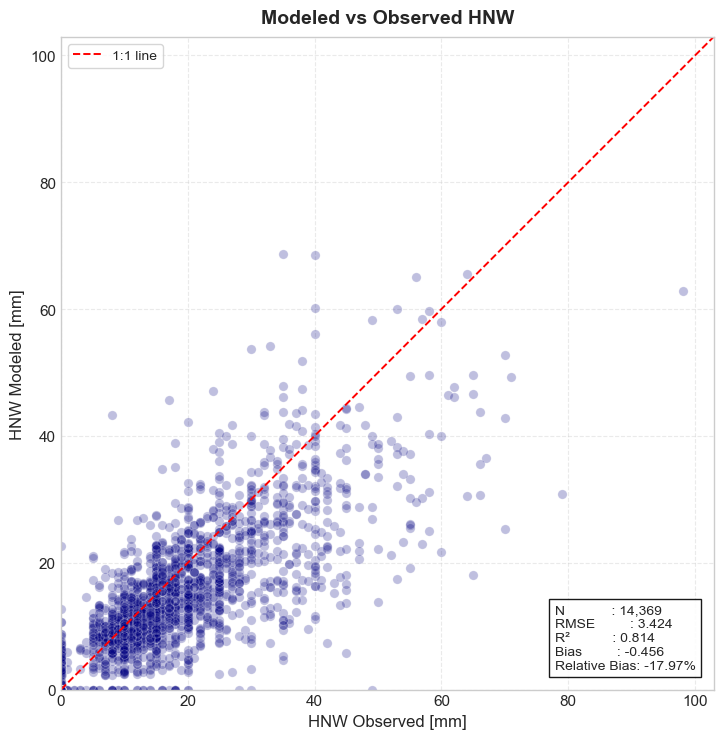

In [33]:
# %% [markdown]
# ### Modeled vs Observed HNW — Clean Scatter with 1:1 and ±Bias Lines
# - Uses your manually selected validated-all-stations CSV.
# - Metrics box (N, RMSE, R², Bias, Relative Bias) inside the plot.
# - Uniform color (no colormap), 1:1 line + ±bias lines.
# - Output figure name based on CSV file's base name (not the full path).

# %%
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
from sklearn import metrics as skm


# -----------------------------
# Manually selected CSV 
# -----------------------------
IN_CSV = "/Users/jakobwerkgarner/code/Master_Delta/calibration/new_snow_rho_HNW/outputs/bulk/validated_all_stations/HNW_validation_df_bulk_2025_07_1016_calib_log_dsnow_calib_Win21forced_high_rho0_drpped_stations_90.0.csv"


# -----------------------------
# 0) Paths
# -----------------------------
BASE_DIR = Path("/Users/jakobwerkgarner/code/Master_Delta")


if calib_language == "python":

    FIG_DIR  = BASE_DIR / "calibration" / "new_snow_rho_HNW" / "outputs"/ "python_calib" / "bulk" / "scatterplot"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    s_rows = 11

else :
    FIG_DIR  = BASE_DIR / "calibration" / "new_snow_rho_HNW" / "outputs" / "bulk" / "scatterplot"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    s_rows = 12

# -----------------------------
# 1) Load + Basic Cleaning
# -----------------------------
df = pd.read_csv(IN_CSV, skiprows= s_rows)

print(f"read the file {IN_CSV}")

df["HNW_obs"] = pd.to_numeric(df["HNW_obs"], errors="coerce")
df["HNW_mod"] = pd.to_numeric(df["HNW_mod"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Keep rows with valid values; guard against negative modeled and observed
df = df.dropna(subset=["date", "station", "HNW_obs", "HNW_mod"]).copy()
df = df[(df["HNW_mod"] >= 0) & (df["HNW_obs"] >= 0)].copy()

# Drop optional columns if present
cols_to_drop = ["year", "month", "doy", "season", "err", "abs_err", "sq_err"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Optional: winter season label
def get_season_label(date):
    if pd.isna(date):
        return None
    if date.month >= 11:
        start_year = date.year
    elif date.month <= 4:
        start_year = date.year - 1
    else:
        return None
    return f"{start_year % 100:02d}{(start_year + 1) % 100:02d}"

df["season"] = df["date"].apply(get_season_label)

# -----------------------------
# 2) Metrics Calculation
# -----------------------------
def calc_mag25_metrics(x, y):
    rmse = np.sqrt(skm.mean_squared_error(x, y))
    r2 = skm.r2_score(x, y)
    bias = np.mean(y - x)
    rel_bias = bias / np.mean(x) if np.mean(x) != 0 else np.nan
    return rmse, r2, bias, rel_bias

x_all = df["HNW_obs"].to_numpy()
y_all = df["HNW_mod"].to_numpy()
rmse, r2, bias, rel_bias = calc_mag25_metrics(x_all, y_all)

# -----------------------------
# 3) Plot — Clean and Professional
# -----------------------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(7.5, 7.5))

# Define limits
min_val = 0.0
max_val = float(max(x_all.max(), y_all.max()))
pad = 0.05 * max_val if max_val > 0 else 1.0
lo, hi = min_val, max_val + pad

# Scatter points (uniform color, no colormap)
ax.scatter(
    x_all, y_all,
    color="navy",
    alpha=0.25,
    s=45,
    linewidths=0.5,
    edgecolors="white"
)

# 1:1 line
ax.plot([lo, hi], [lo, hi], "r--", lw=1.4, label="1:1 line")


# Axis formatting
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", "box")
ax.set_xlabel("HNW Observed [mm]", fontsize=12)
ax.set_ylabel("HNW Modeled [mm]", fontsize=12)
ax.set_title("Modeled vs Observed HNW", fontsize=14, weight="bold", pad=10)
ax.tick_params(axis="both", labelsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=True, fontsize=10, loc="upper left")

# Metrics box
metrics_text = (
    f"N            : {len(x_all):,}\n"
    f"RMSE         : {rmse:.3f}\n"
    f"R²           : {r2:.3f}\n"
    f"Bias         : {bias:.3f}\n"
    f"Relative Bias: {rel_bias:.2%}"
)
at = AnchoredText(metrics_text, prop=dict(size=10), frameon=True, loc="lower right", borderpad=0.9)
at.patch.set_alpha(0.9)
ax.add_artist(at)

plt.tight_layout()

# -----------------------------
# 4) Save Figure
# -----------------------------
csv_name = Path(IN_CSV).stem  # <- just the filename without extension
out_path = FIG_DIR / f"HNW_obs_vs_mod_{csv_name}.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {out_path}")

plt.show()